### 02. PyTorch Neural Network Classification

What is a classification problem? <br>

A classification problem involves predicting whether something is one thing or another.

In [1110]:
# pip install scikit-learn

In [1111]:
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples = 1000

X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

In [1112]:
len(X), len(y)

(1000, 1000)

In [1113]:
print(f'First 5 samples of X:\n {X[:5]}')
print()
print(f'First 5 samples of X:\n {y[:5]}')

First 5 samples of X:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 samples of X:
 [1 1 1 1 0]


In [1114]:
import pandas as pd

circles = pd.DataFrame(
    {
        "X1": X[:, 0],
        "X2": X[:, 1],
        "label": y 
    })

circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


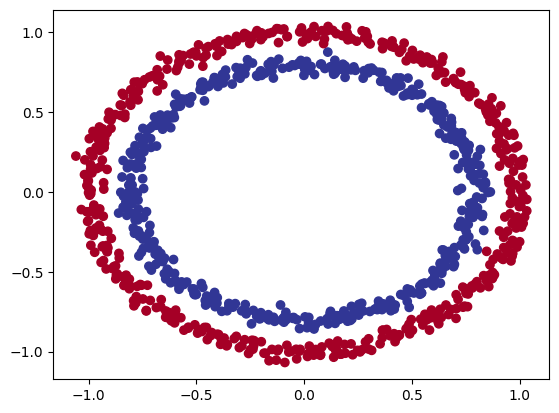

In [1115]:
# Visualize, Visualize, Visualize
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu)

**Note:** The data we're working is often referred to as a toy dataset, a dataset that is small enough to experiment but still sizeable  enought to pratice the fundamentals.

### 1.1 Check input and output shapes

In [1116]:
X.shape, y.shape
# X -> 1000 samples with 2 features
# y -> 1000 samples no Feat

((1000, 2), (1000,))

In [1117]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [1118]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


### 1.2 Turn data into tensors and create train and test splits

In [1119]:
import torch
torch.__version__

'2.8.0+cu129'

In [1120]:
type(X), X.dtype # Run ALL

(numpy.ndarray, dtype('float64'))

In [1121]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float) # float 32 -> default so converting into it
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [1122]:
type(X), X.dtype, y.dtype

(torch.Tensor, torch.float32, torch.float32)

`torch.manual_seed(42)` only works for pytorch

In [1123]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

"""
X_train -> Training Samples and Featurs
X_test -> Testing Samples and Featurs
y_train -> Training labels
y_test -> Testing labels

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
"""

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test), n_samples

(800, 200, 800, 200, 1000)

###  2. Build Model 

We've got some data ready, now it's time to build a model.

We'll break it down into a few parts.

1. Setting up device agnostic code (so our model can run on CPU or GPU if it's available).
2. Constructing a model by subclassing nn.Module.
3. Defining a loss function and optimizer.
4. Creating a training loop (this'll be in the next section).
5. The good news is we've been through all of the above steps before in notebook 01.

Except now we'll be adjusting them so they work with a classification dataset.

Let's start by importing PyTorch and `torch.nn` as well as setting up device agnostic code.

In [1124]:
# Standard PyTorch imports
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Let's create a model class that:

1. Subclasses `nn.Module` (almost all PyTorch models are subclasses of nn.Module).
2. Creates 2 `nn.Linear()` layers in the constructor capable of handling the input and output shapes of X and y.
3. Defines a `forward()`ethod containing the forward pass computation of the model.
4. Instantiates the model class and sends it to the target device.

In [1125]:
# 1. Construct a model that subclasses nn.module

class CircleModelv0(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear layers capable of handling X and y input and output shapes
        # Input Layer

        self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features (X), produces 5 features

        # Hidden Layer -> Also Outputs

        self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features, produces 1 feature (y)
    
        # self.two_linear_layers = nn.Sequential(
        #     nn.Linear(in_features=2, out_features=5),
        #     nn.Linear(in_features=5, out_features=1)
        # )


    # 3. Define a forward method containing the forward pass computation
    def forward(self, x):
        # Return the output of layer_2, a single feature, the same shape as y
        return self.layer_2(self.layer_1(x)) # computation goes through layer_1 first then the output of layer_1 goes through layer_2
        
        # return two_linear_layers(x)

# 4.
model_0 = CircleModelv0().to(device)
model_0, device

(CircleModelv0(
   (layer_1): Linear(in_features=2, out_features=5, bias=True)
   (layer_2): Linear(in_features=5, out_features=1, bias=True)
 ),
 'cuda')

**`nn.Sequential`** -> Implements above for us behind the scene.

`nn.Sequential` in PyTorch is a container module designed to simplify the construction of neural networks by organizing layers in a linear, sequential order. It is a subclass of nn.Module and provides a convenient way to define models where the output of one layer directly becomes the input of the next.

In [1126]:
# Replicate CircleModelV0 with nn.Sequential
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [1127]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]], device='cuda:0')),
             ('0.bias',
              tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]], device='cuda:0')),
             ('1.bias', tensor([-0.1213], device='cuda:0'))])

In [1128]:
# Make predictions with the model
untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967],
        [ 0.2968],
        [ 0.1405],
        [ 0.2178],
        [ 0.0805],
        [-0.0284]], device='cuda:0', grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


### 2.1 Setup loss function and optimizer
We've setup a loss (also called a criterion or cost function) and optimizer before in notebook 01.

But different problem types require different loss functions.

For example, for a regression problem (predicting a number) you might use mean absolute error (MAE) loss.

And for a binary classification problem (like ours), you'll often use binary cross entropy as the loss function.

However, the same optimizer function can often be used across different problem spaces.

For example, the stochastic gradient descent optimizer (SGD, torch.optim.SGD()) can be used for a range of problems, and the same applies to the Adam optimizer (torch.optim.Adam()).

Loss function measures how wrong the model's predictions are 

https://docs.pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html#torch.nn.BCEWithLogitsLoss


In [1129]:
# Create a loss function
# loss_fn = nn.BCELoss() # BCELoss = no sigmoid built-in
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), 
                            lr=0.1)

In [1130]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100 
    return acc

### 3. Train Loop for Model

To Train model, training loop with following steps:

1. Forward Pass
2. Calculate the Loss
3. Optimizer zero grad
4. Loss Backward ( backpropagation )
5. Optimizer Step ( gradient Descent )

#### 3.1 Going from raw logits -> prediction probablities -> prediction labels

Our model outputs are going to be raw **logits**.

We can convert these **logits** into **prediction probabilities** by passing them to some kind of activation function (e.g. sigmoid for binary classification and softmax for multiclass classification).

Then we can convert our model's prediction probabilities to **prediction labels** by either ***rounding them*** or taking the `argmax()`.

**logits** are the raw, unnormalized output scores from a neural network's final layer before any activation function is applied. 

In [1131]:
# View the first 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]], device='cuda:0')

In [1132]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [1133]:
# use the sigmoid activation function on our model logits to turn them into prediciton probablities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4916],
        [0.4923],
        [0.5223],
        [0.4827],
        [0.5736]], device='cuda:0')

in our case, since we're dealing with binary classification, our ideal outputs are 0 or 1.

So these values can be viewed as a decision boundary.

The closer to 0, the more the model thinks the sample belongs to class 0, the closer to 1, the more the model thinks the sample belongs to class 1.

for our prediction probablity values, we need to perform a range-style rounding on them: 

- If y_pred_probs >= 0.5, y=1 (class 1)
- If y_pred_probs < 0.5, y=0 (class 0)

In [1134]:
# Find the predicted labels (round the prediction probabilities)
y_preds = torch.round(y_pred_probs)

# In full ( logits -> pred probs -> pred labels)
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze() # random as weights are random too not trained yet

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 1., 0., 1.], device='cuda:0')

In [1135]:
y_test[:5] # Ideal labels values to be achieve.

tensor([1., 0., 1., 0., 1.])

In [1136]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 9000

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
for epoch in range(epochs):
    ### Training
    model_0.train()

    # 1. Forward pass (model outputs raw logits)
    y_logits = model_0(X_train).squeeze() # squeeze to remove extra `1` dimensions, this won't work unless model and data are on same device 
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labls
  
    # 2. Calculate loss/accuracy
    # loss = loss_fn(torch.sigmoid(y_logits), # Using nn.BCELoss you need torch.sigmoid()
    #                y_train) 
    loss = loss_fn(y_logits, # Using nn.BCEWithLogitsLoss works with raw logits
                   y_train) 
    acc = accuracy_fn(y_true=y_train, 
                      y_pred=y_pred) 

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_0.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_0(X_test).squeeze() 
        test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Caculate loss/accuracy
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred=test_pred)

    # Print out what's happening every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69796, Accuracy: 51.88% | Test loss: 0.69440, Test acc: 58.00%
Epoch: 10 | Loss: 0.69590, Accuracy: 51.25% | Test loss: 0.69305, Test acc: 53.00%
Epoch: 20 | Loss: 0.69490, Accuracy: 51.62% | Test loss: 0.69254, Test acc: 49.50%
Epoch: 30 | Loss: 0.69435, Accuracy: 51.12% | Test loss: 0.69236, Test acc: 49.50%
Epoch: 40 | Loss: 0.69401, Accuracy: 50.88% | Test loss: 0.69232, Test acc: 51.00%


Epoch: 50 | Loss: 0.69378, Accuracy: 50.25% | Test loss: 0.69234, Test acc: 50.00%
Epoch: 60 | Loss: 0.69362, Accuracy: 50.00% | Test loss: 0.69239, Test acc: 51.50%
Epoch: 70 | Loss: 0.69351, Accuracy: 50.25% | Test loss: 0.69246, Test acc: 51.00%
Epoch: 80 | Loss: 0.69342, Accuracy: 49.88% | Test loss: 0.69254, Test acc: 50.00%
Epoch: 90 | Loss: 0.69336, Accuracy: 49.88% | Test loss: 0.69262, Test acc: 53.00%
Epoch: 100 | Loss: 0.69331, Accuracy: 49.25% | Test loss: 0.69271, Test acc: 53.00%
Epoch: 110 | Loss: 0.69327, Accuracy: 49.75% | Test loss: 0.69279, Test acc: 54.00%
Epoch: 120 | Loss: 0.69324, Accuracy: 50.25% | Test loss: 0.69286, Test acc: 53.00%
Epoch: 130 | Loss: 0.69321, Accuracy: 49.75% | Test loss: 0.69294, Test acc: 55.00%
Epoch: 140 | Loss: 0.69319, Accuracy: 50.62% | Test loss: 0.69301, Test acc: 54.00%
Epoch: 150 | Loss: 0.69317, Accuracy: 52.25% | Test loss: 0.69307, Test acc: 51.00%
Epoch: 160 | Loss: 0.69315, Accuracy: 51.38% | Test loss: 0.69314, Test acc: 56.0

In [1137]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


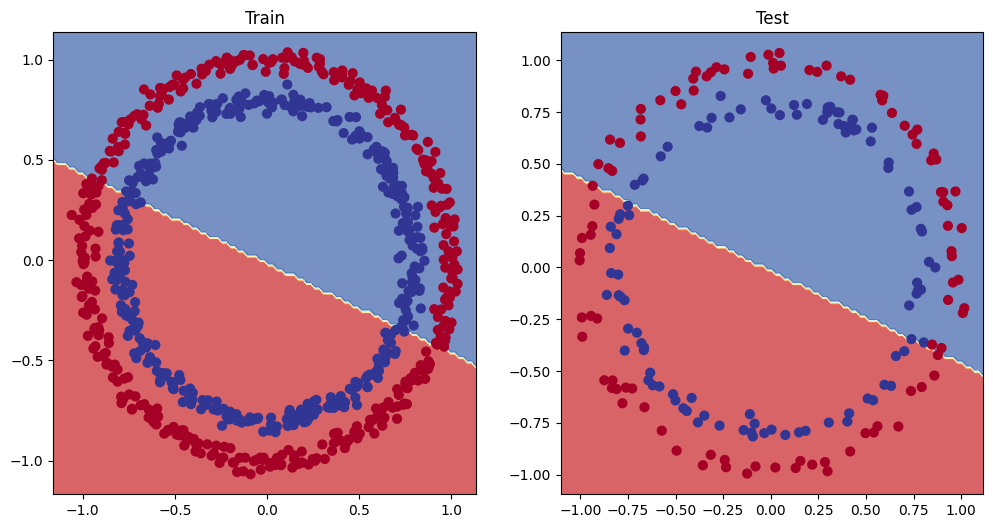

In [1138]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

### 5. Improving a model (from a model perspective)

- Add more layers - give the model more chances to learn patterns in the data
- Add more hidden units - go from 5 hidden units to 10 hidden units  ( neurons)
- Fit for longer 
- changing the actication func
- change the Lr
- change the loss func

These options are all from a model's perspective because they deal directly with the model, rather than the data

and because these options are all values we ( as machine learning engineers ) can change, they are called hyperparameters.

Let's try and improve our model by: 
- adding more hidden units: 5 -> 10
- increase the number of layers: 2 -> 3
- incerase the number of epochs: 100 -> 1000

In [1139]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10) # extra layer
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        
    def forward(self, x): # note: always make sure forward is spelt correctly!
        # Creating a model like this is the same as below, though below
        # generally benefits from speedups where possible.
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        # return z
        return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [1140]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0794, -0.2676],
                      [ 0.4846, -0.4836],
                      [-0.3287, -0.1962],
                      [-0.4357,  0.0310],
                      [-0.6777,  0.6946]])),
             ('0.bias', tensor([-0.6069,  0.5209,  0.1151, -0.2190,  0.4238])),
             ('1.weight',
              tensor([[ 0.0317,  0.2030, -0.0471, -0.1442,  0.2224]])),
             ('1.bias', tensor([-0.2059]))])

In [1141]:
model_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984], device='cuda:0')),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.122

In [1142]:
# Create a loss function
loss_fn = nn.BCEWithLogitsLoss()

# Optimizer 
optimizer = torch.optim.SGD(
        params=model_1.parameters(),
        lr=0.0002
    )

In [1143]:
torch.manual_seed(42)

epochs = 1000 # Train for longer

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    ### Training
    # 1. Forward pass
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilities -> prediction labels

    # 2. Calculate loss/accuracy
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, 
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_1(X_test).squeeze() 
        test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Caculate loss/accuracy
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred=test_pred)

    # Print out what's happening every 10 epochs
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.69396, Accuracy: 50.88% | Test loss: 0.69261, Test acc: 51.00%
Epoch: 100 | Loss: 0.69395, Accuracy: 50.75% | Test loss: 0.69261, Test acc: 51.00%
Epoch: 200 | Loss: 0.69394, Accuracy: 50.75% | Test loss: 0.69261, Test acc: 51.00%
Epoch: 300 | Loss: 0.69394, Accuracy: 50.75% | Test loss: 0.69261, Test acc: 51.00%
Epoch: 400 | Loss: 0.69393, Accuracy: 50.62% | Test loss: 0.69261, Test acc: 51.00%
Epoch: 500 | Loss: 0.69392, Accuracy: 50.50% | Test loss: 0.69261, Test acc: 51.00%
Epoch: 600 | Loss: 0.69392, Accuracy: 50.62% | Test loss: 0.69262, Test acc: 51.00%
Epoch: 700 | Loss: 0.69391, Accuracy: 50.62% | Test loss: 0.69262, Test acc: 51.00%
Epoch: 800 | Loss: 0.69390, Accuracy: 50.62% | Test loss: 0.69262, Test acc: 50.50%
Epoch: 900 | Loss: 0.69390, Accuracy: 50.62% | Test loss: 0.69262, Test acc: 50.50%


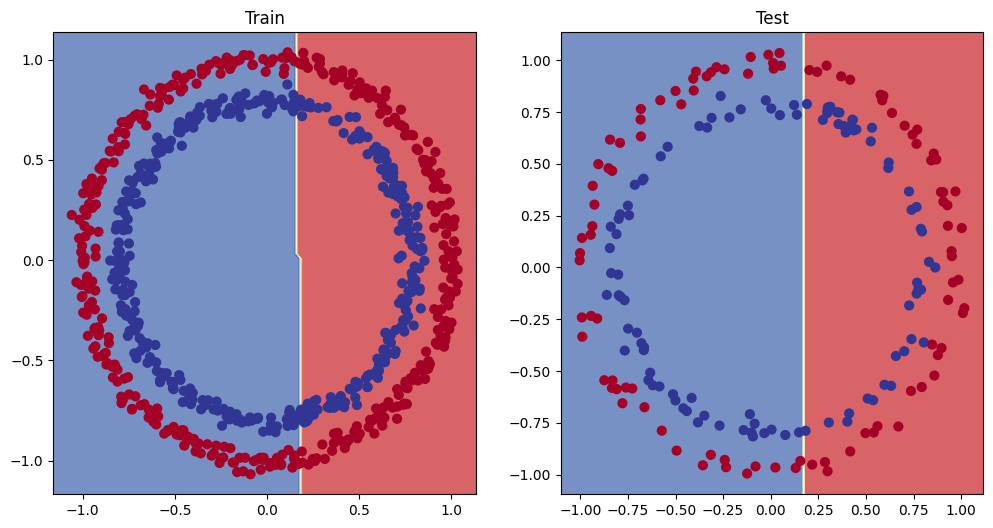

In [1144]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

### 5.1 Preparing data to see if our model can model a straight line

Let's create some linear data to see if our model's able to model it and we're not just using a model that can't learn anything.

In [1145]:
# Create some data (same as notebook 01)
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# Create data
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias # linear regression formula

# Check the data
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [1146]:
# Create train and test splits
train_split = int(0.8 * len(X_regression)) # 80% of data used for training set
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

# Check the lengths of each split
print(len(X_train_regression), 
    len(y_train_regression), 
    len(X_test_regression), 
    len(y_test_regression))

80 80 20 20


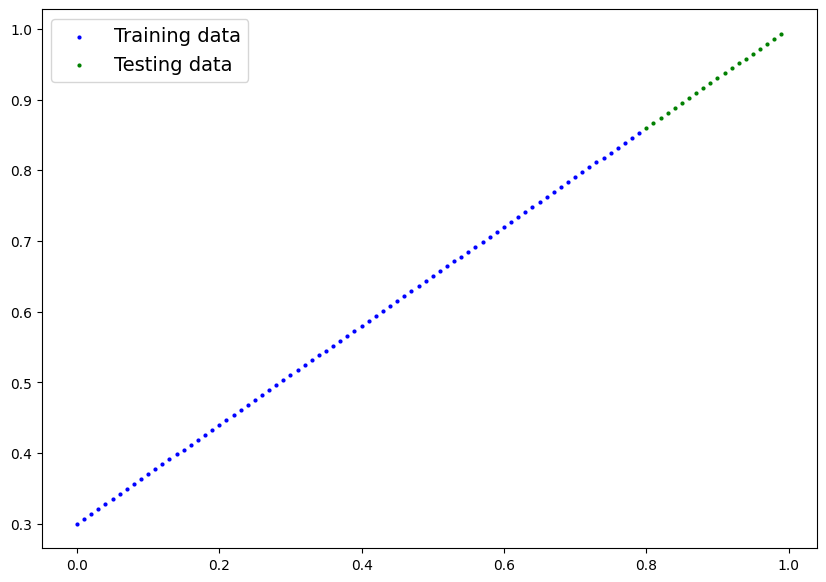

In [1147]:
plot_predictions(train_data=X_train_regression,
    train_labels=y_train_regression,
    test_data=X_test_regression,
    test_labels=y_test_regression
);

### 5.2 Adjusting `model_1` to fit a staright line

In [1148]:
# Same architecture as model_1 (but using nn.Sequential)
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [1149]:
# Loss and optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.01)

In [1150]:
# Train the model
torch.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put data to target device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
    ### Training 
    # 1. Forward pass
    y_pred = model_2(X_train_regression)
    
    # 2. Calculate loss (no accuracy since it's a regression problem, not classification)
    loss = loss_fn(y_pred, y_train_regression)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_2.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_pred = model_2(X_test_regression)
      # 2. Calculate the loss 
      test_loss = loss_fn(test_pred, y_test_regression)

    # Print out what's happening
    if epoch % 100 == 0: 
        print(f"Epoch: {epoch} | Train loss: {loss:.5f}, Test loss: {test_loss:.5f}")


Epoch: 0 | Train loss: 0.75986, Test loss: 0.91103
Epoch: 100 | Train loss: 0.02858, Test loss: 0.00081
Epoch: 200 | Train loss: 0.02533, Test loss: 0.00209
Epoch: 300 | Train loss: 0.02137, Test loss: 0.00305
Epoch: 400 | Train loss: 0.01964, Test loss: 0.00341
Epoch: 500 | Train loss: 0.01940, Test loss: 0.00387
Epoch: 600 | Train loss: 0.01903, Test loss: 0.00379
Epoch: 700 | Train loss: 0.01878, Test loss: 0.00381
Epoch: 800 | Train loss: 0.01840, Test loss: 0.00329
Epoch: 900 | Train loss: 0.01798, Test loss: 0.00360


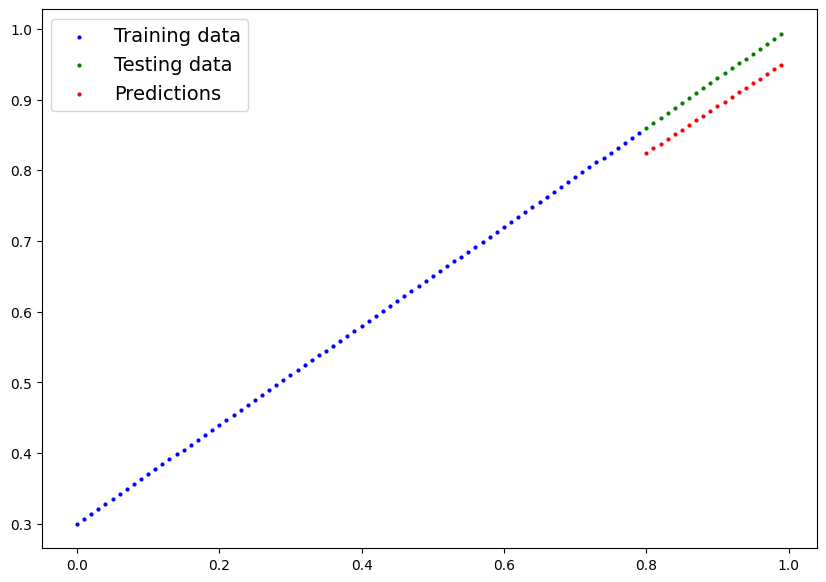

In [1151]:
# turn on evaluation mode
model_2.eval()

# Make Predicitons (inference)
with torch.inference_mode():
    y_preds = model_2(X_test_regression)

# plot data and predicitons
plot_predictions(train_data=X_train_regression.cpu(),
                 train_labels=y_train_regression.cpu(),
                 test_data=X_test_regression.cpu(),
                test_labels=y_test_regression.cpu(),
                predictions=y_preds.cpu()
                );

## 6. the missing point: non-linearity

### 6.1 Recreating non-linear Data ( red and blue circles )

First, let's recreate the data to start off fresh. We'll use the same setup as before.

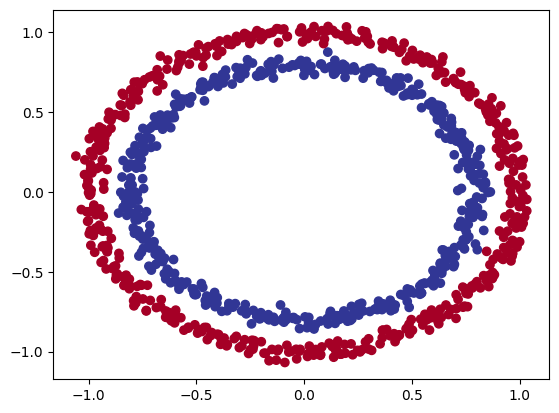

In [1152]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples=1000,
    noise=0.03,
    random_state=42,
)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu);

Nice! Now let's split it into training and test sets using 80% of the data for training and 20% for testing.

In [1153]:
# Convert to tensors and split into train and test sets
import torch
from sklearn.model_selection import train_test_split

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2,
                                                    random_state=42
)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 6.2 Building a model with non-linearity
- Linear - straight line 
- non-linear - non-straight line

In [1154]:
# Build model with non-linear activation function
from torch import nn
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # <- add in ReLU activation function  # coz of this there is improvemetn in training.
        # Can also put sigmoid in the model 
        # This would mean you don't need to use it on the predictions
        # self.sigmoid = nn.Sigmoid()

    def forward(self, x):
      # Intersperse the ReLU activation function between layers
       return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
print(model_3)

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


In [1155]:
# Setup loss and optimizer 
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(), lr=0.1)

### 6.3 Training a model with non-linearity


In [1156]:
# Fit the model
torch.manual_seed(42)
epochs = 1000

# Put all data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    # 1. Forward pass
    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilities -> prediction labels
    
    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train) # BCEWithLogitsLoss calculates loss using logits
    acc = accuracy_fn(y_true=y_train, 
                      y_pred=y_pred)
    
    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_3.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model_3(X_test).squeeze()
      test_pred = torch.round(torch.sigmoid(test_logits)) # logits -> prediction probabilities -> prediction labels
      
      # 2. Calculate loss and accuracy
      test_loss = loss_fn(test_logits, y_test)
      test_acc = accuracy_fn(y_true=y_test,
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69295, Accuracy: 50.00% | Test Loss: 0.69319, Test Accuracy: 50.00%
Epoch: 100 | Loss: 0.69115, Accuracy: 52.88% | Test Loss: 0.69102, Test Accuracy: 52.50%
Epoch: 200 | Loss: 0.68977, Accuracy: 53.37% | Test Loss: 0.68940, Test Accuracy: 55.00%
Epoch: 300 | Loss: 0.68795, Accuracy: 53.00% | Test Loss: 0.68723, Test Accuracy: 56.00%
Epoch: 400 | Loss: 0.68517, Accuracy: 52.75% | Test Loss: 0.68411, Test Accuracy: 56.50%
Epoch: 500 | Loss: 0.68102, Accuracy: 52.75% | Test Loss: 0.67941, Test Accuracy: 56.50%
Epoch: 600 | Loss: 0.67515, Accuracy: 54.50% | Test Loss: 0.67285, Test Accuracy: 56.00%
Epoch: 700 | Loss: 0.66659, Accuracy: 58.38% | Test Loss: 0.66322, Test Accuracy: 59.00%
Epoch: 800 | Loss: 0.65160, Accuracy: 64.00% | Test Loss: 0.64757, Test Accuracy: 67.50%
Epoch: 900 | Loss: 0.62362, Accuracy: 74.00% | Test Loss: 0.62145, Test Accuracy: 79.00%


### 6.4 Evaluating a model trained with non-linear activation functions

In [1157]:
# Make Predictions
model_3.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()

y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 0., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

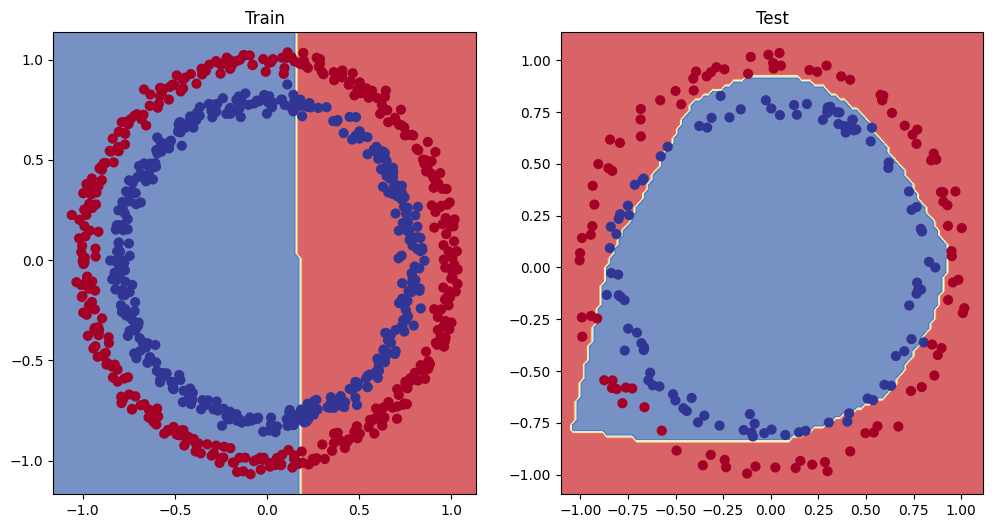

In [1158]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train) # model_1 = no non-linearity

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test) # model_3 = has non-linearity

## 7. Replicating non-linear activation functions¶

In [1159]:
# Create a toy tensor (similar to the data going into our model(s))
A = torch.arange(-10, 10, 1, dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

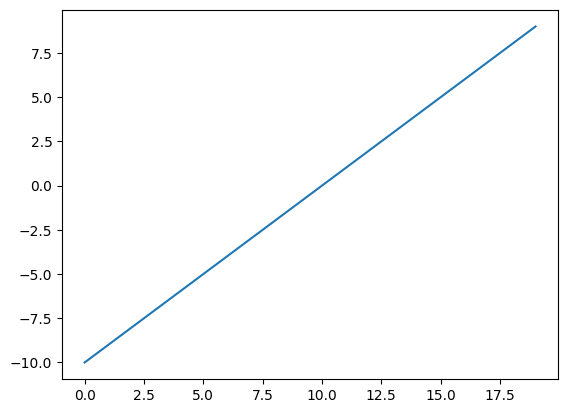

In [1160]:
# Visualize the toy tensor
plt.plot(A);

A straight line, nice.

Now let's see how the ReLU activation function influences it.

And instead of using PyTorch's ReLU (torch.nn.ReLU), we'll recreate it ourselves.

The ReLU function turns all negatives to 0 and leaves the positive values as they are.

In [1161]:
# Create ReLU function by hand 
def relu(x):
  return torch.maximum(torch.tensor(0), x) # inputs must be tensors

# Pass toy tensor through ReLU function
relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

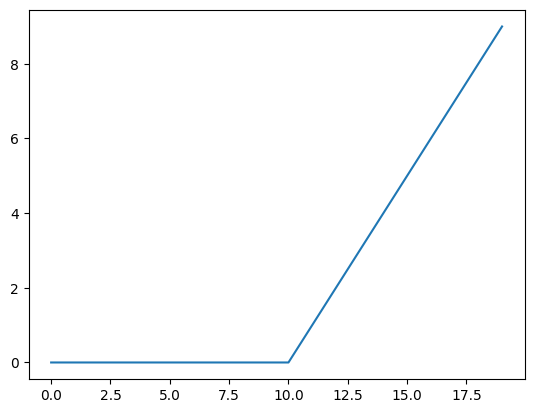

In [1162]:
plt.plot(relu(A))

In [1163]:
# Create a custom sigmoid function
def sigmoid(x):
  return 1 / (1 + torch.exp(-x))

# Test custom sigmoid on toy tensor
sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

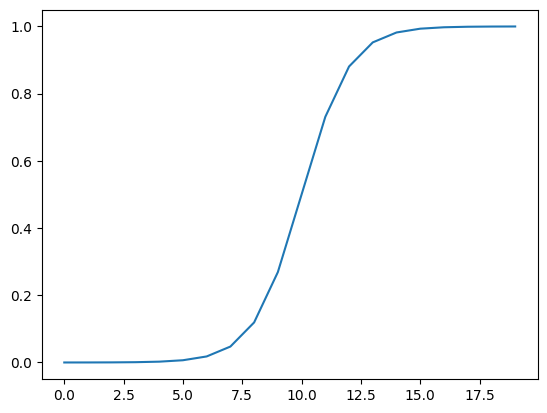

In [1164]:
# Plot sigmoid activated toy tensor
plt.plot(sigmoid(A));

## 8. Putting it all together with a multi-class classification problem
- binary classification = one thing or another ( cat vs dog, spam vs not spam, fraud or not fraud )
- multi-class classification = more than one thing or another ( cat vs dog vs bird )



### 8.1 Creating a Toy multi-class dataset

tensor([[ -8.7147,   5.1372,   1.5585],
        [  3.0065, -11.5325,   8.7140],
        [  1.8581,  -8.4531,  10.3169],
        [ -5.2194,   8.5004,   1.9934],
        [  4.5265,  -6.5185,  -2.9776]]) tensor([2, 3, 3, 2, 1])


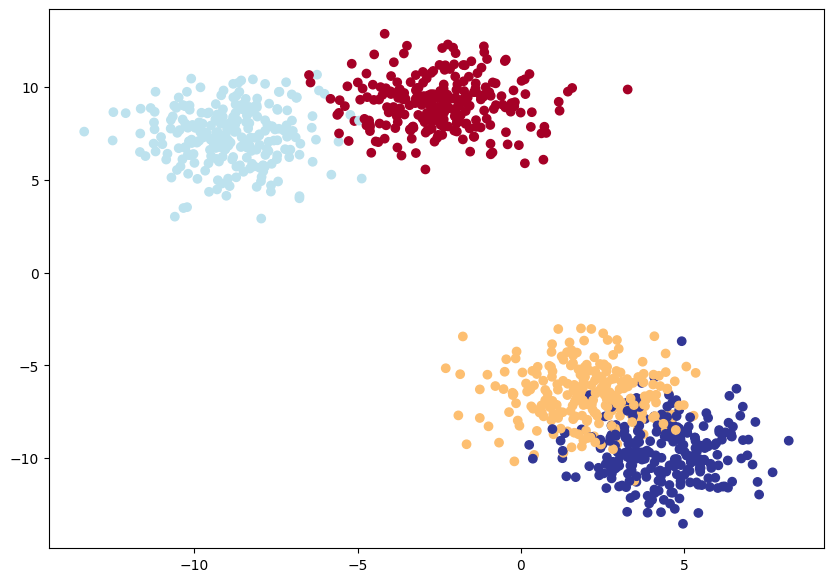

In [1165]:
# Import dependencies
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 3
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples=1000,
    n_features=NUM_FEATURES, # X features
    centers=NUM_CLASSES, # y labels 
    cluster_std=1.5, # give the clusters a little shake up (try changing this to 1.0, the default)
    random_state=RANDOM_SEED
)

# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)
print(X_blob[:5], y_blob[:5])

# 3. Split into train and test sets
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
    y_blob,
    test_size=0.2,
    random_state=RANDOM_SEED
)

# 4. Plot data
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu);

### 8.2 Building a multi-class classification model in pytorch


In [1166]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [1167]:

# Build model
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        """Initializes all required hyperparameters for a multi-class classification model.

        Args:
            input_features (int): Number of input features to the model.
            out_features (int): Number of output features of the model
              (how many classes there are).
            hidden_units (int): Number of hidden units between layers, default 8.
        """
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            # nn.ReLU(), # <- does our dataset require non-linear layers? (try uncommenting and see if the results change)
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            # nn.ReLU(), # <- does our dataset require non-linear layers? (try uncommenting and see if the results change)
            nn.Linear(in_features=hidden_units, out_features=output_features), # how many classes are there?
        )
    
    def forward(self, x):
        return self.linear_layer_stack(x)

# Create an instance of BlobModel and send it to the target device
model_4 = BlobModel(input_features=NUM_FEATURES, 
                    output_features=NUM_CLASSES, 
                    hidden_units=8).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=3, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [1168]:
X_blob_train.shape, X_blob_train[0], y_blob_train[:10]
model_4.state_dict()

OrderedDict([('linear_layer_stack.0.weight',
              tensor([[ 0.4414,  0.4792, -0.1353],
                      [ 0.5304, -0.1265,  0.1165],
                      [-0.2811,  0.3391,  0.5090],
                      [-0.4236,  0.5018,  0.1081],
                      [ 0.4266,  0.0782,  0.2784],
                      [-0.0815,  0.4451,  0.0853],
                      [-0.2695,  0.1472, -0.2660],
                      [-0.0677, -0.2345,  0.3830]], device='cuda:0')),
             ('linear_layer_stack.0.bias',
              tensor([-0.4557, -0.2662, -0.1630, -0.3471,  0.0545, -0.5702,  0.5214, -0.4904],
                     device='cuda:0')),
             ('linear_layer_stack.1.weight',
              tensor([[ 0.2730,  0.0588, -0.1148,  0.2185,  0.0551,  0.2857,  0.0387, -0.1115],
                      [ 0.0950, -0.0959,  0.1488,  0.3157,  0.2044, -0.1546,  0.2041,  0.0633],
                      [ 0.1795, -0.2155, -0.3500, -0.1366, -0.2712,  0.2901,  0.1018,  0.1464],
                

### 8.3 Creating a loss function and optimizer for a multi-class PyTorch model¶


In [1169]:
# Create loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_4.parameters(), 
                            lr=0.1) # exercise: try changing the learning rate here and seeing what happens to the model's performance

### 8.4 Getting prediction probabilities for a multi-class PyTorch model

in order to evaluate and train our model, we need to convert our model's outputs (logits) to prediction probablities and 

Logits(raw output of the model) -> Pred probs(use `torch.softmax`) -> Pred labels ( take the argmax of the prediciton probablities)

In [1170]:
 # Let's get some raw outputs of our model (logits)
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test.to(device))

y_logits[:10]

tensor([[ 1.5775,  0.9536,  0.3863, -2.3549],
        [-0.7344, -0.6327,  0.1146,  0.7396],
        [-0.6946, -0.5650,  0.1204,  1.0523],
        [ 1.4438,  0.8477,  0.3705, -2.3705],
        [-0.4124, -0.5807,  0.1434, -0.4261],
        [ 1.6506,  0.9842,  0.3944, -2.6388],
        [-0.3342, -0.3756,  0.1615, -0.0233],
        [-0.5413, -0.4996,  0.1384,  0.2878],
        [-0.9595, -0.7683,  0.0911,  0.7620],
        [ 1.2452,  0.7105,  0.3459, -1.8698]], device='cuda:0')

In [1171]:
y_blob_test[:10]

tensor([3, 1, 1, 3, 2, 3, 1, 1, 1, 3])

In [1172]:
# Convert our model's logit outputs to prediction probablities
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[ 1.5775,  0.9536,  0.3863, -2.3549],
        [-0.7344, -0.6327,  0.1146,  0.7396],
        [-0.6946, -0.5650,  0.1204,  1.0523],
        [ 1.4438,  0.8477,  0.3705, -2.3705],
        [-0.4124, -0.5807,  0.1434, -0.4261]], device='cuda:0')
tensor([[0.5378, 0.2882, 0.1634, 0.0105],
        [0.1135, 0.1256, 0.2653, 0.4956],
        [0.0987, 0.1123, 0.2229, 0.5661],
        [0.5222, 0.2877, 0.1785, 0.0115],
        [0.2186, 0.1847, 0.3811, 0.2156]], device='cuda:0')


In [1173]:
# Convert our model's prediction prob to pred labels
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds

tensor([0, 3, 3, 0, 2, 0, 2, 3, 3, 0, 0, 2, 0, 2, 2, 0, 2, 0, 0, 2, 3, 3, 0, 0,
        0, 0, 3, 3, 3, 2, 2, 3, 3, 2, 2, 3, 3, 0, 0, 2, 0, 0, 2, 2, 3, 0, 0, 3,
        3, 2, 2, 2, 3, 2, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 3, 2, 3, 2, 2, 2, 3, 2,
        2, 3, 0, 2, 2, 0, 2, 0, 0, 3, 0, 2, 2, 2, 3, 0, 2, 2, 3, 3, 0, 2, 2, 0,
        0, 3, 0, 0, 2, 0, 3, 2, 3, 3, 3, 2, 3, 3, 0, 0, 2, 0, 2, 2, 2, 3, 0, 2,
        0, 0, 3, 2, 0, 0, 2, 0, 2, 0, 0, 0, 0, 2, 2, 2, 0, 2, 2, 0, 2, 0, 2, 2,
        0, 3, 2, 3, 3, 2, 0, 0, 0, 0, 2, 3, 0, 0, 2, 2, 0, 2, 0, 0, 2, 2, 2, 0,
        0, 0, 2, 0, 2, 2, 0, 0, 3, 2, 2, 0, 0, 2, 2, 3, 0, 2, 2, 2, 0, 3, 2, 2,
        0, 2, 2, 3, 3, 3, 0, 3], device='cuda:0')

In [1183]:
y_blob_test

tensor([3, 1, 1, 3, 2, 3, 1, 1, 1, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 0, 1, 2, 3, 3,
        0, 3, 1, 2, 1, 2, 0, 1, 1, 2, 0, 1, 1, 3, 3, 0, 3, 3, 0, 2, 1, 3, 3, 1,
        1, 2, 2, 0, 1, 2, 3, 0, 2, 2, 2, 2, 0, 0, 3, 3, 1, 0, 1, 2, 2, 0, 1, 0,
        0, 1, 3, 2, 2, 3, 2, 2, 0, 1, 0, 2, 2, 2, 1, 3, 2, 2, 1, 1, 3, 2, 2, 0,
        3, 1, 3, 3, 0, 0, 1, 0, 1, 1, 1, 2, 1, 1, 3, 3, 2, 3, 0, 0, 2, 1, 3, 1,
        3, 3, 1, 2, 0, 0, 2, 3, 0, 3, 3, 3, 3, 0, 2, 0, 3, 2, 2, 0, 2, 3, 2, 0,
        3, 1, 2, 1, 1, 2, 3, 3, 3, 3, 0, 1, 3, 0, 0, 0, 3, 2, 0, 0, 0, 2, 0, 0,
        3, 3, 2, 3, 0, 2, 3, 3, 1, 1, 2, 3, 3, 2, 2, 1, 3, 1, 2, 0, 3, 1, 2, 0,
        3, 0, 2, 1, 1, 1, 0, 1], device='cuda:0')

### 8.5 Creating a training and testing loop for a multi-class PyTorch model

In [1184]:
# Fit the model
torch.manual_seed(42)

# Set number of epochs
epochs = 100

# Put data to target device
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    ### Training
    model_4.train()

    # 1. Forward pass
    y_logits = model_4(X_blob_train) # model outputs raw logits 
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # go from logits -> prediction probabilities -> prediction labels
    # print(y_logits)
    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_blob_train) 
    acc = accuracy_fn(y_true=y_blob_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_4.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model_4(X_blob_test)
      test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
      # 2. Calculate test loss and accuracy
      test_loss = loss_fn(test_logits, y_blob_test)
      test_acc = accuracy_fn(y_true=y_blob_test,#
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%") 

RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cuda:0, different from other tensors on cpu (when checking argument in method wrapper_CUDA_addmm)

### 8.6 making and evaluating predicitons with a pytorch multi-class model

In [ ]:
# Make predictions
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test)

# View the first 10 predictions
y_logits[:10]

tensor([[  0.3469,  -3.7434,  -9.3802,   7.9245],
        [ -8.4204,   7.5570,   2.1403,  -2.1716],
        [ -8.4594,   8.4352,  -0.6803,  -0.6341],
        [ -0.6135,  -3.2539,  -7.5184,   6.7582],
        [ -0.0804,  -1.1086,   8.1947,  -5.2244],
        [  0.6488,  -4.5933,  -8.4376,   7.5692],
        [ -7.3565,   5.3536,   1.5698,  -1.1238],
        [ -9.2590,   7.2711,   1.9675,  -1.6206],
        [-12.9187,  10.6166,   3.9119,  -3.2247],
        [  0.5579,  -3.0943,  -7.4827,   6.2422]], device='cuda:0')

In [ ]:
y_pred_prob = torch.softmax(y_logits, dim=1)
y_pred_probs[:10]

tensor([[0.5378, 0.2882, 0.1634, 0.0105],
        [0.1135, 0.1256, 0.2653, 0.4956],
        [0.0987, 0.1123, 0.2229, 0.5661],
        [0.5222, 0.2877, 0.1785, 0.0115],
        [0.2186, 0.1847, 0.3811, 0.2156],
        [0.5519, 0.2834, 0.1571, 0.0076],
        [0.2014, 0.1932, 0.3306, 0.2748],
        [0.1586, 0.1653, 0.3129, 0.3633],
        [0.0938, 0.1135, 0.2682, 0.5245],
        [0.4909, 0.2876, 0.1997, 0.0218]], device='cuda:0')

In [ ]:
y_blob_test[:10]

tensor([3, 1, 1, 3, 2, 3, 1, 1, 1, 3], device='cuda:0')

In [ ]:
# Turn predicted logits in prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)

# Turn prediction probabilities into prediction labels
y_preds = y_pred_probs.argmax(dim=1)

# Compare first 10 model preds and test labels
print(f"Predictions: {y_preds[:10]}\nLabels: {y_blob_test[:10]}")
print(f"Test accuracy: {accuracy_fn(y_true=y_blob_test, y_pred=y_preds)}%")

Predictions: tensor([3, 1, 1, 3, 2, 3, 1, 1, 1, 3], device='cuda:0')
Labels: tensor([3, 1, 1, 3, 2, 3, 1, 1, 1, 3], device='cuda:0')
Test accuracy: 100.0%


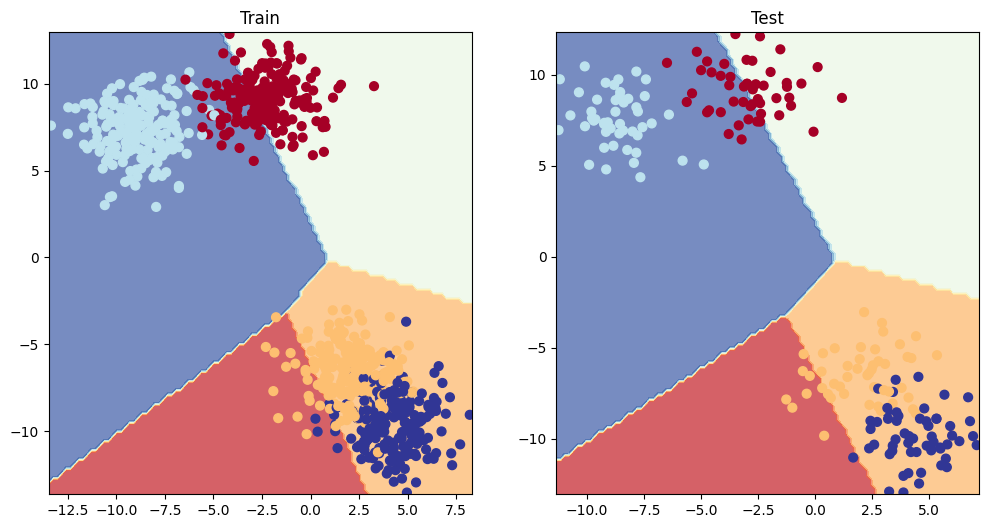

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

### 9. A few more classification metrics..( to evaluate our classification model)
- Accuracy - out of 100 samples, how many does our model get right?
- precision
- Recall
- F1-Score
- Confusion Score
- Classification Report

In [1189]:
# !pip install torchmetrics

In [1190]:
from torchmetrics import  Accuracy

# setup matric
torchmetrics_accuracy = Accuracy().to(device)

# Calculate Accuracy
torchmetric_accuracy(y_preds, y_blob_test)

TypeError: Accuracy.__new__() missing 1 required positional argument: 'task'